    # MODULO5 Talento Altamente Especializado --> IA

    *Professor**: Dr German Pinedo
    **Nombre**: Cesar Eduardo Inda Ceniceros  

# M5.3 Denoising Autoencoder (DAE)

A denoising autoencoder receives a corrupted image $\tilde{x}$ but learns to reconstruct the clean image $x$:

$$\tilde{x} \rightarrow \text{Encoder} \rightarrow z \rightarrow \text{Decoder} \rightarrow \hat{x} \approx x$$

This example uses **MNIST** resized to $32\times32$. Gaussian noise is sampled again for every training batch, so the network learns to recover the clean digit rather than memorize one fixed corruption.


In [1]:
!pip install torchinfo umap-learn
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchinfo import summary

EPOCHS = 10
BATCH_SIZE = 16
NOISE_STD = 0.30

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")


   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.1 MB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.8 MB 1.1 MB/s eta 0:00:02
   -------------- ------------------------- 1.0/2.8 MB 1.1 MB/s eta 0:00:02
   ------------------ --------------------- 1.3/2.8 MB 1.2 MB/s eta 0:00:02
   ---------------------- ----------------- 1.6/2.8 MB 1.2 MB/s eta 0:00:02
   -------------------------- ------------- 1.8/2.8 MB 1.3 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.8 MB 1.3 MB/s eta 0:00:01
   ------------------------------------- -- 2.6/2.8 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 1.4 MB/s  0:00:02
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------

In [2]:
def add_noise(x, std=NOISE_STD):
    """Add Gaussian noise to images assumed to be in [0, 1]."""
    return (x + std * torch.randn_like(x)).clamp(0, 1)


def collect_latents(model, loader):
    """Encode a fixed labeled subset for latent-space visualization."""
    was_training = model.training
    model.eval()

    latents, labels = [], []
    with torch.no_grad():
        for clean, y in loader:
            z = model.encode(clean.to(device))
            latents.append(z.flatten(1).cpu())
            labels.append(y.cpu())

    if was_training:
        model.train()

    return torch.cat(latents).numpy(), torch.cat(labels).numpy()


def train_dae(model, train_loader, epochs=EPOCHS, lr=1e-3,
              latent_loader=None, latent_epochs=None):
    """Train with noisy inputs and clean reconstruction targets."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    latent_epochs = set(latent_epochs or [])
    latent_history = {}

    # Epoch 0: representation before any parameter update.
    if latent_loader is not None and 0 in latent_epochs:
        z, y = collect_latents(model, latent_loader)
        latent_history[0] = {"z": z, "y": y}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for clean, _ in train_loader:
            clean = clean.to(device)
            noisy = add_noise(clean)

            optimizer.zero_grad()
            output = model(noisy)
            loss = criterion(output, clean)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * clean.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)

        if epoch == 1 or epoch % 2 == 0 or epoch == epochs:
            print(f"epoch {epoch:2d}/{epochs} - loss: {epoch_loss:.6f}")

        if latent_loader is not None and epoch in latent_epochs:
            z, y = collect_latents(model, latent_loader)
            latent_history[epoch] = {"z": z, "y": y}

    return history, latent_history


def show_dae_reconstruction(clean, noisy, output, title=""):
    """Show clean target, noisy input, reconstruction, and absolute error."""
    clean = clean.detach().cpu().squeeze()
    noisy = noisy.detach().cpu().squeeze()
    output = output.detach().cpu().squeeze()
    diff = (clean - output).abs()

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    images = [clean, noisy, output, diff]
    names = ["clean", "noisy input", "reconstruction", "|clean - output|"]
    cmaps = ["gray", "gray", "gray", "magma"]

    for ax, img, name, cmap in zip(axes, images, names, cmaps):
        im = ax.imshow(img, cmap=cmap)
        ax.set_title(name)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## 2D convolutional DAE

The encoder reduces spatial resolution while increasing feature maps. The decoder reverses the process. The bottleneck is obtained with `encode(x)`.


In [3]:
class ConvBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            ConvBlock2D(in_channels, out_channels),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels, final=False):
        super().__init__()
        # Primero hacemos upsampling con cambio de canales
        layers = [nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)]

        if final:
            # Capa final: solo una convolución para refinar + sigmoid
            layers += [
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.Sigmoid(),
            ]
        else:
            # Capas intermedias: ConvBlock para procesar la salida
            layers += [ConvBlock2D(out_channels, out_channels)]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Autoencoder2D(nn.Module):
    def __init__(self, in_channels=1, initial_channels=8,
                 latent_channels=32, depth=3):
        super().__init__()

        # Construir lista de canales
        channels = [in_channels]
        for i in range(depth):
            channels.append(initial_channels * 2**i)
        channels.append(latent_channels)

        # Pares encoder (forward)
        encoder_pairs = list(zip(channels[:-1], channels[1:]))

        # Pares decoder (reverse)
        decoder_pairs = list(zip(reversed(channels[1:]), reversed(channels[:-1])))

        # Build encoder
        self.encoder = nn.Sequential(
            *[DownBlock2D(in_ch, out_ch) for in_ch, out_ch in encoder_pairs]
        )

        # Build decoder
        self.decoder = nn.Sequential(
            *[UpBlock2D(in_ch, out_ch, final=(i == len(decoder_pairs) - 1))
              for i, (in_ch, out_ch) in enumerate(decoder_pairs)]
        )

    def encode(self, x):
        for block in self.encoder:
            x = block(x)
        return x

    def decode(self, z):
        for block in self.decoder:
            z = block(z)
        return z

    def forward(self, x):
        return self.decode(self.encode(x))


100%|██████████| 9.91M/9.91M [00:08<00:00, 1.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 326kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


Training samples: 1000
Training batches: 63
UMAP samples: 1500


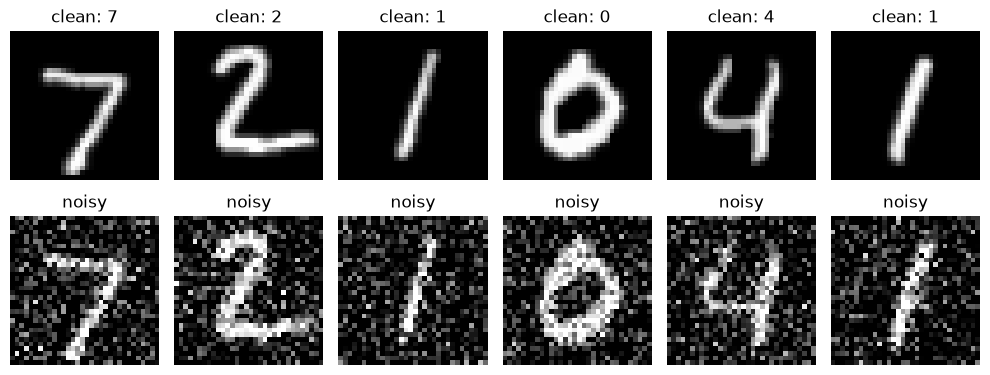

In [4]:
# MNIST: [1, 28, 28] -> [1, 32, 32]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

train_dataset_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# --------------------------------------------------
# Use only 1,000 training examples
# --------------------------------------------------

generator = torch.Generator().manual_seed(42)

train_indices = torch.randperm(
    len(train_dataset_full),
    generator=generator
)[:1000]

train_dataset = Subset(
    train_dataset_full,
    train_indices
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

# --------------------------------------------------
# Fixed subset only for latent-space visualization
# --------------------------------------------------

umap_subset = Subset(
    test_dataset,
    range(1500)
)

umap_loader = DataLoader(
    umap_subset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

print(f"Training samples: {len(train_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"UMAP samples: {len(umap_subset)}")

# One fixed test batch for reconstruction visualization.
x_test, y_test = next(iter(test_loader))
torch.manual_seed(8)
x_test_noisy = add_noise(x_test)

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for i in range(6):
    axes[0, i].imshow(x_test[i, 0], cmap="gray")
    axes[0, i].set_title(f"clean: {y_test[i].item()}")
    axes[1, i].imshow(x_test_noisy[i, 0], cmap="gray")
    axes[1, i].set_title("noisy")
    axes[0, i].axis("off")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [5]:
init_channels = 8
latent_channels = 32
depth = 4
ae = Autoencoder2D(
    in_channels=1,
    initial_channels=init_channels,
    latent_channels=latent_channels,
    depth=depth,
)

x_sample, _ = next(iter(train_loader))
summary(
    ae,
    input_data=x_sample[:1],
    col_names=("input_size", "output_size", "num_params"),
    depth=2,
)


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
Autoencoder2D                                      [1, 1, 32, 32]            [1, 1, 32, 32]            --
├─Sequential: 1-1                                  --                        --                        --
│    └─DownBlock2D: 2-1                            [1, 1, 32, 32]            [1, 8, 16, 16]            96
│    └─DownBlock2D: 2-2                            [1, 8, 16, 16]            [1, 16, 8, 8]             1,200
│    └─DownBlock2D: 2-3                            [1, 16, 8, 8]             [1, 32, 4, 4]             4,704
│    └─DownBlock2D: 2-4                            [1, 32, 4, 4]             [1, 64, 2, 2]             18,624
│    └─DownBlock2D: 2-5                            [1, 64, 2, 2]             [1, 32, 1, 1]             18,528
├─Sequential: 1-2                                  --                        --                        --
│    └─UpBlock2D: 2-6      

In [6]:
# Save a few latent snapshots so we can visualize epoch 0 -> N.
latent_epochs = sorted(set([0, 1, 2, 5, EPOCHS]))

history, latent_history = train_dae(
    ae,
    train_loader,
    epochs=EPOCHS,
    latent_loader=umap_loader,
    latent_epochs=latent_epochs,
)


epoch  1/10 - loss: 0.142441
epoch  2/10 - loss: 0.081485
epoch  4/10 - loss: 0.037340
epoch  6/10 - loss: 0.027457
epoch  8/10 - loss: 0.023570
epoch 10/10 - loss: 0.021182


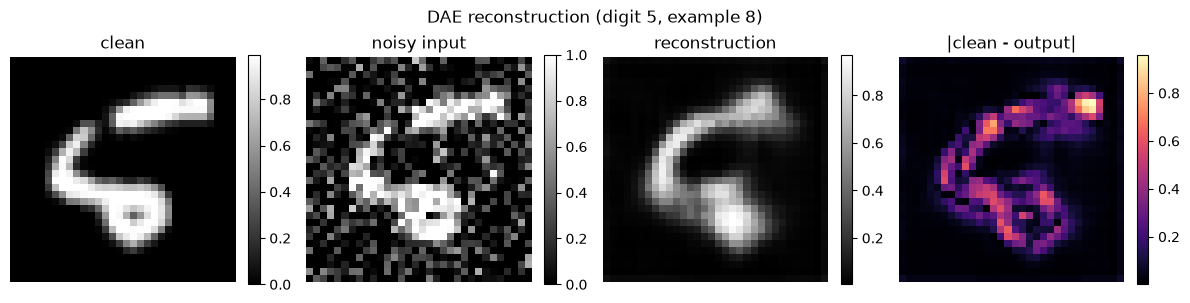

In [7]:
ae.eval()

with torch.no_grad():
    output = ae(x_test_noisy.to(device)).cpu()

idx = torch.randint(0, x_test.shape[0], (1,)).item()

show_dae_reconstruction(
    x_test[idx],
    x_test_noisy[idx],
    output[idx],
    title=f"DAE reconstruction (digit {y_test[idx].item()}, example {idx})"
)


c:\Users\tiori\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


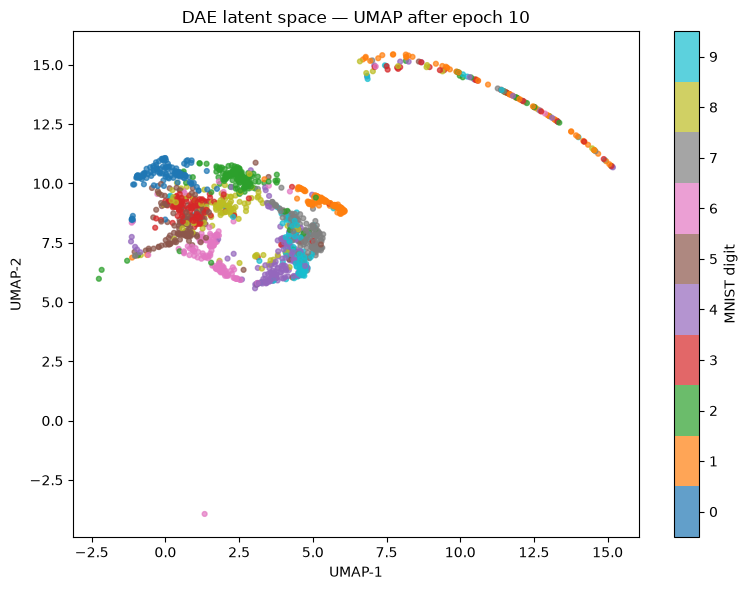

In [8]:
# Latent-space UMAP: final projection + evolution from epoch 0 to N.
# If needed once in a fresh environment: pip install umap-learn
try:
    import umap
except ImportError as exc:
    raise ImportError("Install UMAP with: pip install umap-learn") from exc

from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

epochs = sorted(latent_history)

# Fit one UMAP jointly to all saved epochs. This keeps a common 2D coordinate
# system across animation frames and avoids arbitrary frame-to-frame rotations.
all_latents = np.concatenate([latent_history[e]["z"] for e in epochs], axis=0)
labels = latent_history[epochs[0]]["y"]

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.15,
    metric="euclidean",
    random_state=7,
)
embedding_all = reducer.fit_transform(all_latents)

n = len(labels)
embedding_by_epoch = {
    epoch: embedding_all[i*n:(i+1)*n]
    for i, epoch in enumerate(epochs)
}

# Final latent space.
final_epoch = epochs[-1]
Z = embedding_by_epoch[final_epoch]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    Z[:, 0], Z[:, 1],
    c=labels, cmap="tab10", vmin=-0.5, vmax=9.5,
    s=12, alpha=0.70,
)
ax.set_title(f"DAE latent space — UMAP after epoch {final_epoch}")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
cbar = fig.colorbar(sc, ax=ax, ticks=range(10))
cbar.set_label("MNIST digit")
plt.tight_layout()
plt.show()

# Animation: same MNIST examples and same UMAP coordinate system at every frame.
xy_all = np.concatenate(list(embedding_by_epoch.values()), axis=0)
pad = 0.5
xlim = (xy_all[:, 0].min() - pad, xy_all[:, 0].max() + pad)
ylim = (xy_all[:, 1].min() - pad, xy_all[:, 1].max() + pad)

fig, ax = plt.subplots(figsize=(8, 6))
Z0 = embedding_by_epoch[epochs[0]]
sc = ax.scatter(
    Z0[:, 0], Z0[:, 1],
    c=labels, cmap="tab10", vmin=-0.5, vmax=9.5,
    s=12, alpha=0.70,
)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
title = ax.set_title("")

def update(frame):
    epoch = epochs[frame]
    Z = embedding_by_epoch[epoch]
    sc.set_offsets(Z)
    title.set_text(f"DAE latent space — epoch {epoch}")
    return sc, title

anim = FuncAnimation(
    fig, update, frames=len(epochs),
    interval=900, blit=False, repeat=True,
)
plt.close(fig)
display(HTML(anim.to_jshtml()))
